# **Sensitivity Analysis, Model Comparison & Holdout Results**

Sections:
1. Setup
2. Lookback Window
3. Number of Pairs
4. Transaction Costs
5. Hedge Ratio Method (OLS vs Kalman)
6. Entry/Exit Thresholds (Quantile Sweep)
7. Stop-Loss Threshold
8. Min Pair Score Threshold
9. Sensitivity Summary
10. Per-Fold Robustness of Best Configuration
11. Holdout Results (2017 - final unbiased test)

## **1. Setup**

In [1]:
%matplotlib inline

from __future__ import annotations
import sys
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#4c72b0"
ORANGE = "#dd8452"
RED = "#c44e52"
GREEN = "#55a868"
PURPLE = "#8172b2"
MODEL_COLORS = [BLUE, ORANGE, GREEN, RED, PURPLE]


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/config.py")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest.backtest_engine import BacktestConfig, BacktestEngine, ZScoreSignal
from src.backtest.quantile_zscore_signal import QuantileZScoreSignal
from src.config import DEFAULT_CONFIG, DEFAULT_BACKTEST_PARAMS

PROCESSED = DEFAULT_CONFIG.processed_dir

# hyperparameter grids
LOOKBACK_GRID = [20, 40, 63, 126, 252] # rolling z-score lookback (days)
N_PAIRS_GRID = [10, 20, 30, 50, 75] # number of pairs per window
TC_BPS_GRID = [0, 5, 10, 20, 30] # transaction cost (bps per side)
ENTRY_QS = [0.03, 0.05, 0.07, 0.10] # entry quantile levels
EXIT_QS = [0.30, 0.40, 0.50] # exit quantile levels
STOP_QS = [0.01, 0.0] # stop-loss quantile levels

# fixed defaults used when sweeping other parameters
DEFAULT_ENTRY_Z = DEFAULT_BACKTEST_PARAMS.entry_z
DEFAULT_EXIT_Z = DEFAULT_BACKTEST_PARAMS.exit_z
DEFAULT_STOP_Z = DEFAULT_BACKTEST_PARAMS.stop_z
DEFAULT_LOOKBACK = DEFAULT_BACKTEST_PARAMS.rolling_lookback
DEFAULT_N_PAIRS = DEFAULT_BACKTEST_PARAMS.n_top_pairs
DEFAULT_TC_BPS = DEFAULT_BACKTEST_PARAMS.transaction_cost_bps


# helper functions
def make_engine(
    n_top_pairs: int = DEFAULT_N_PAIRS,
    transaction_cost_bps: float = DEFAULT_TC_BPS,
    rolling_lookback: int = DEFAULT_LOOKBACK,
    use_rolling_zscore: bool = True,
    pairs_path: str | None = None,
) -> BacktestEngine:
    cfg = BacktestConfig(
        entry_z = DEFAULT_ENTRY_Z,
        exit_z = DEFAULT_EXIT_Z,
        stop_z = DEFAULT_STOP_Z,
        n_top_pairs = n_top_pairs,
        transaction_cost_bps = transaction_cost_bps,
        use_rolling_zscore = use_rolling_zscore,
        rolling_lookback = rolling_lookback,
    )
    engine = BacktestEngine(cfg)
    engine.load_data(
        str(DEFAULT_CONFIG.engineered_features_path),
        pairs_path or str(PROCESSED / "discovered_pairs.csv"),
    )
    return engine


def run_and_extract(engine: BacktestEngine, signal = None) -> dict:
    # Run validation and return aggregate metrics + per-fold Sharpes.
    results = engine.run(signal_generator=signal)
    agg = results.get("__aggregate__", {})
    metrics = dict(agg.get("metrics", {}))
    fold_sharpes = [
        v.get("metrics", {}).get("sharpe", 0.0)
        for k, v in results.items() if k != "__aggregate__"
    ]
    metrics["mean_fold_sharpe"] = float(np.mean(fold_sharpes)) if fold_sharpes else 0.0
    metrics["std_fold_sharpe"] = float(np.std(fold_sharpes))  if fold_sharpes else 0.0
    metrics["fold_sharpes"] = fold_sharpes
    return metrics


def line_chart(df, x_col, x_label, title, out_metrics=None):
    # Line chart for up to 3 metrics across a sensitivity grid.
    if out_metrics is None:
        out_metrics = [("sharpe", "Sharpe"), ("annualized_return", "Ann. Return"), ("max_drawdown", "Max Drawdown")]
    fig, axes = plt.subplots(1, len(out_metrics), figsize = (5 * len(out_metrics), 4))
    if len(out_metrics) == 1:
        axes = [axes]
    colors = [BLUE, ORANGE, RED]
    for ax, (metric, label), color in zip(axes, out_metrics, colors):
        if metric not in df.columns:
            continue
        ax.plot(df[x_col], df[metric], marker = "o", color = color, linewidth = 1.5)
        ax.set_xlabel(x_label)
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.axhline(0, color = "black", linewidth = 0.7, linestyle = "--")
    fig.suptitle(title, fontsize = 12, y = 1.02)
    plt.tight_layout()
    plt.show()

## **2. Lookback Window**

How much does the rolling z-score lookback window affect strategy performance?
A flat line means the strategy is robust to this parameter.

Lookback = 20 days...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

[2010_2012]  selected= 50  |  tradable= 50  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=ZScoreSignal
[2011_2013]  selected= 29  |  tradable= 29  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=ZScoreSignal
[2012_2014]  selected= 50  |  tradable= 50  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=ZScoreSignal
[2013_2015]  selected= 50  |  tradable= 50  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=ZScoreSignal
Lookback = 40 days...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  →

,lookback,sharpe,fitness,annualized_return,max_drawdown,turnover,n_trades
0,20,-1.4111,-0.0525,-0.0266,-0.1108,19.2197,3375
1,40,-0.9691,-0.0383,-0.0193,-0.0970,12.3017,2165
2,63,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
3,126,-0.1962,-0.0050,-0.0029,-0.0420,4.6134,827
4,252,-0.2930,-0.0107,-0.0029,-0.0275,2.1434,377


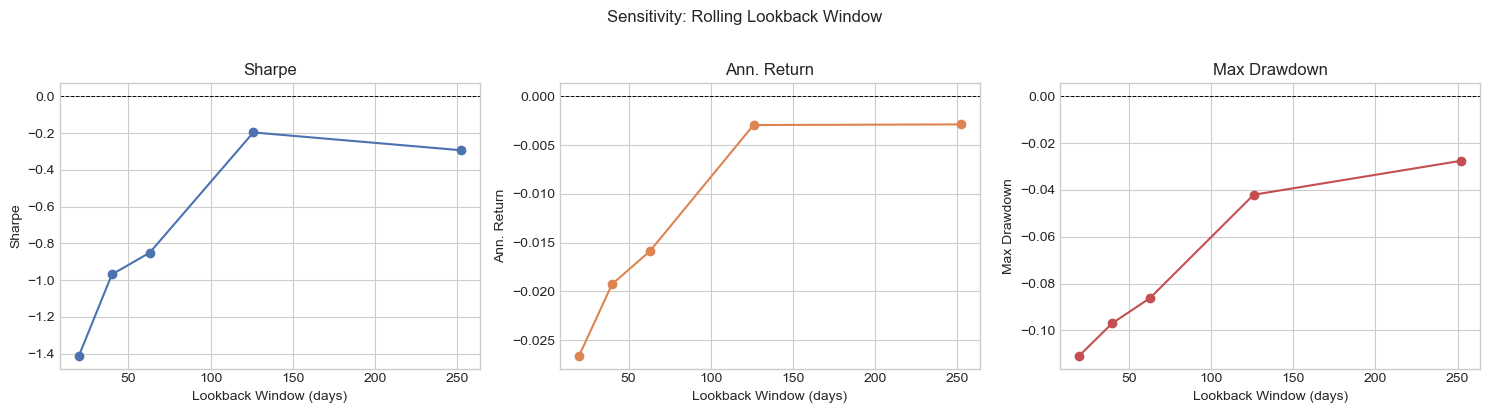

In [2]:
lb_rows = []
for lb in LOOKBACK_GRID:
    print(f"Lookback = {lb} days...")
    m = run_and_extract(make_engine(rolling_lookback = lb, use_rolling_zscore = True))
    m["lookback"] = lb
    lb_rows.append(m)

lb_df = pd.DataFrame(lb_rows)
display(lb_df[["lookback", "sharpe", "fitness", "annualized_return",
               "max_drawdown", "turnover", "n_trades"]].round(4))
line_chart(lb_df, "lookback", "Lookback Window (days)", "Sensitivity: Rolling Lookback Window")

### Interpretation: Lookback Window Sensitivity
**Lookback window definition**:

A 20-day lookback means the strategy only remembers the last 20 days of price history when deciding whether to make a trade. A 252-day lookback means it remembers a full year. The question being tested here is: how much memory does the strategy need to make good decisions? 

**The results show**: 

As the lookback window grows from 20 → 126 days, every metric improves monotonically. Sharpe goes from -1.41 to -0.2, drawdown shrinks from -11.08% to -4.2%, and turnover drops from 19.22 to 4.61. Then at 252 days performance worsens again (-0.29 Sharpe).

**Conclusion/takeaway**: 

+ Longer lookbacks are better but it's about losing less, not becoming profitable.
+ The more the strategy trades, the worse it does because every trade has a cost, and most of the extra trades at short lookbacks are mistakes. This is a common problem called overtrading.
+ The strategy exhibits strong sensitivity to the lookback window at short horizons (20–63 days). Performance stabilises at 126 days, suggesting the pairs require approximately one trading half-year to establish reliable mean-reversion behaviour. The 252-day window slightly underperforms 126 days, likely because a full year of history includes outdated price behaviour that no longer reflects how the stock pair currently moves together.

## **3. Number of Pairs**

Does adding more pairs improve or dilute returns?

N pairs = 10...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

[2010_2012]  selected= 10  |  tradable= 10  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=ZScoreSignal
[2011_2013]  selected= 10  |  tradable= 10  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=ZScoreSignal
[2012_2014]  selected= 10  |  tradable= 10  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=ZScoreSignal
[2013_2015]  selected= 10  |  tradable= 10  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=ZScoreSignal
N pairs = 20...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 ticke

,n_pairs,sharpe,fitness,annualized_return,max_drawdown,turnover,n_trades
0,10,-0.6083,-0.0280,-0.0175,-0.0968,8.2500,328
1,20,-0.5413,-0.0215,-0.0132,-0.0979,8.3500,665
2,30,-0.6116,-0.0243,-0.0131,-0.0804,8.2851,978
3,50,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
4,75,-0.8428,-0.0356,-0.0150,-0.0784,8.3925,1949


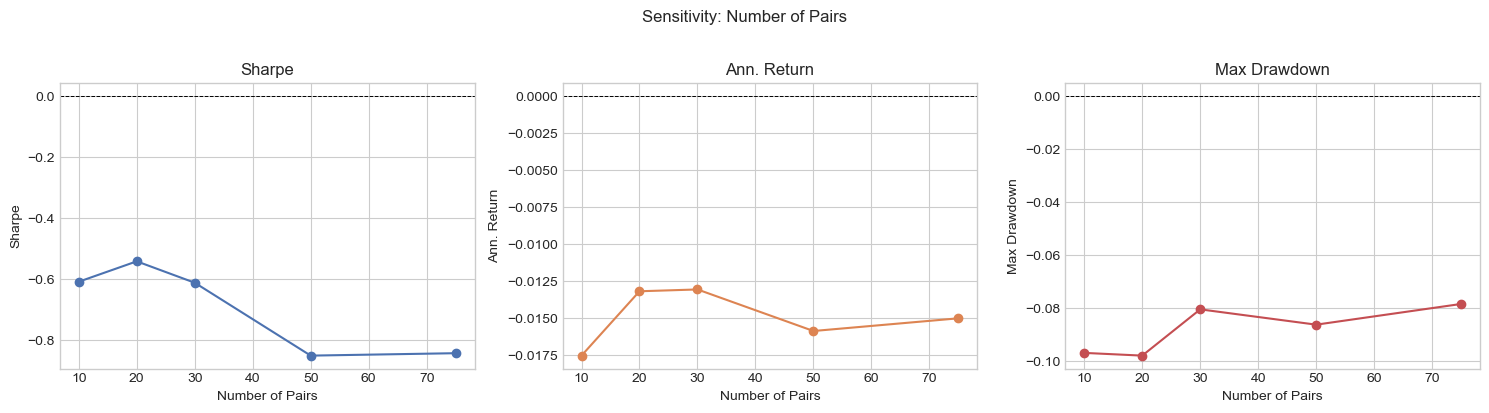

In [3]:
np_rows = []
for n in N_PAIRS_GRID:
    print(f"N pairs = {n}...")
    m = run_and_extract(make_engine(n_top_pairs = n))
    m["n_pairs"] = n
    np_rows.append(m)

np_df = pd.DataFrame(np_rows)
display(np_df[["n_pairs", "sharpe", "fitness", "annualized_return",
               "max_drawdown", "turnover", "n_trades"]].round(4))
line_chart(np_df, "n_pairs", "Number of Pairs", "Sensitivity: Number of Pairs")

### Interpretation: Number of Pairs Sensitivity
**What this testing is for**:
Instead of trading just one stock pair, the strategy trades multiple pairs simultaneously. This tests whether trading more pairs improves performance.

**What the results show**: The optimal number of pairs to trade is around 20 pairs (Sharpe = -0.54). Performance gets worse if you trade less than or beyond 20 pairs.

## **4. Transaction Costs**

How quickly does performance degrade as trading costs increase?
A strategy that only works at 0 bps is not realistically deployable.

TC = 0 bps...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

[2010_2012]  selected= 50  |  tradable= 50  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=ZScoreSignal
[2011_2013]  selected= 29  |  tradable= 29  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=ZScoreSignal
[2012_2014]  selected= 50  |  tradable= 50  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=ZScoreSignal
[2013_2015]  selected= 50  |  tradable= 50  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=ZScoreSignal
TC = 5 bps...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers |

,tc_bps,sharpe,fitness,annualized_return,max_drawdown,turnover,n_trades
0,0,0.0514,0.0005,0.0010,-0.0561,8.4817,1511
1,5,-0.4007,-0.0119,-0.0075,-0.0713,8.4817,1511
2,10,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
3,20,-1.7345,-0.1072,-0.0324,-0.1310,8.4817,1511
4,30,-2.5801,-0.1955,-0.0487,-0.1862,8.4817,1511


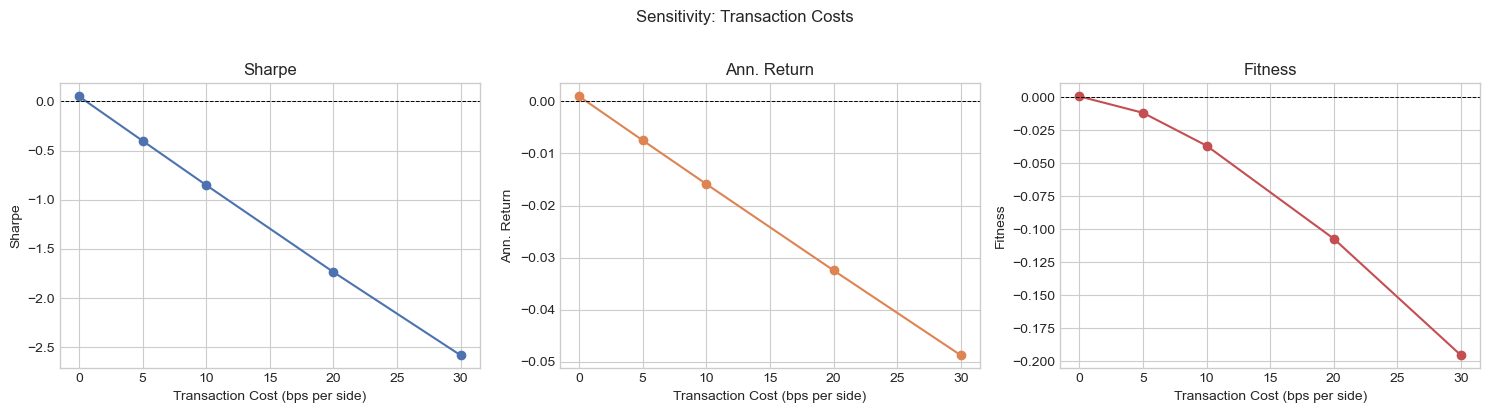

In [10]:
tc_rows = []
for tc in TC_BPS_GRID:
    print(f"TC = {tc} bps...")
    m = run_and_extract(make_engine(transaction_cost_bps=tc))
    m["tc_bps"] = tc
    tc_rows.append(m)

tc_df = pd.DataFrame(tc_rows)
display(tc_df[["tc_bps", "sharpe", "fitness", "annualized_return",
               "max_drawdown", "turnover", "n_trades"]].round(4))
line_chart(tc_df, "tc_bps", "Transaction Cost (bps per side)", "Sensitivity: Transaction Costs",
           out_metrics=[("sharpe", "Sharpe"), ("annualized_return", "Ann. Return"), ("fitness", "Fitness")])

### Interpretation: Transaction Cost Sensitivity
**Transaction cost definition**:

Every time you buy or sell a stock, you pay a small fee to brokers, exchanges, and through the bid-ask spread (the tiny gap between buying and selling prices). "Bps" stands for basis points, where 1 bps = 0.01%. So 10 bps means you pay 0.10% of the trade value every time you trade. In real markets, 5–10 bps per side is a realistic minimum for institutional traders.

**What the results show**:
+ At 0 bps. a theoretical scenario with no trading fees, the strategy barely breaks even (Sharpe = 0.05, annual return = 0.10%). This is the only configuration across the sensitivity analysis where the strategy is profitable.
+ At a realistic cost of 10 bps, performance drops to Sharpe = -0.79, and continues declining linearly to -2.42 at 30 bps. Since the number of trades remains constant at 1,511 regardless of cost level, the strategy makes no attempt to reduce trading when costs are high.

**Conclusion/takeaway**:
+ The strategy's gross profit (before costs) is extremely thin. 
+ The linear decline tells us the problem is the strategy trades too much. Every trade costs money and the gains from each trade are not large enough to cover those costs. This connects back to the lookback window finding: longer lookbacks = fewer trades = less cost drag.

## **5. Hedge Ratio Method (OLS vs Kalman)**

Visualise how much the Kalman beta drifts from the static OLS beta over each window,
and compare the resulting spread stationarity (mean |z-score|) to see which method produces
a more mean-reverting spread.

Aggregated across all pairs per window:


,window,n_pairs,ols_mean_abs_z_mean,ols_mean_abs_z_median,kalman_mean_abs_z_mean,kalman_mean_abs_z_median,kalman_beta_std_mean,kalman_beta_std_median,kalman_beta_range_mean,kalman_beta_range_median,kalman_vs_ols_deviation_mean,kalman_vs_ols_deviation_median
0,2010_2012,20,1.0682,1.0632,1.0033,0.9802,0.0427,0.0467,0.1410,0.1453,0.9384,0.8624
1,2011_2013,20,1.0905,1.0845,1.0616,1.0581,0.0557,0.0172,0.1802,0.0604,0.4850,0.3497
2,2012_2014,20,1.0715,1.0728,1.0145,1.0002,0.0611,0.0375,0.2147,0.1361,0.7964,0.7048
3,2013_2015,20,1.0760,1.0798,1.0031,0.9946,0.0388,0.0222,0.1325,0.0851,0.4986,0.3578
4,2014_2016,20,1.0543,1.0557,0.9958,0.9847,0.0335,0.0215,0.1128,0.0801,0.6565,0.7634


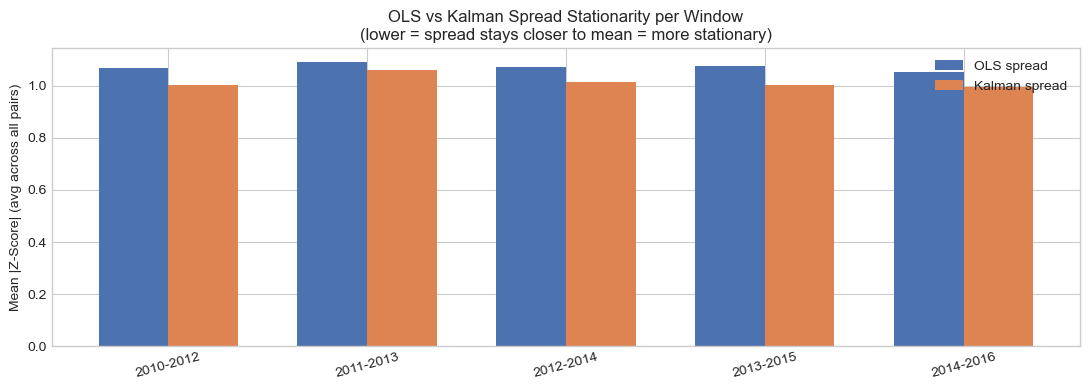

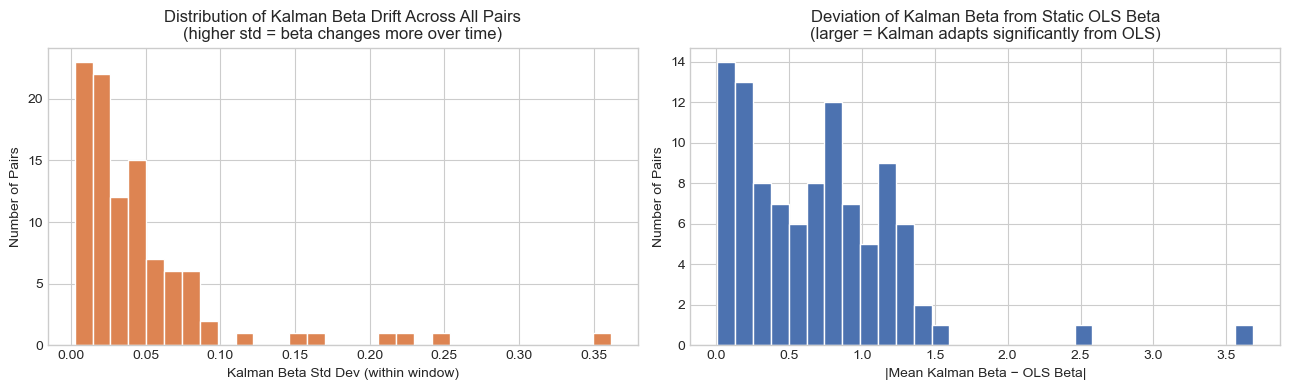

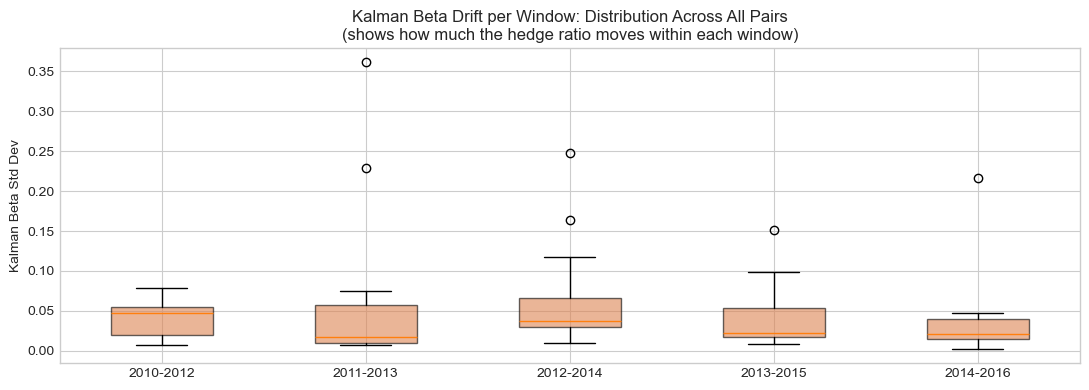

In [5]:
pair_dataset_windows = sorted([p.name for p in (PROCESSED / "pair_datasets").iterdir() if p.is_dir()])
pairs_csv = PROCESSED / "discovered_pairs.csv"
pairs_meta = pd.read_csv(pairs_csv) if pairs_csv.exists() else pd.DataFrame()

window_rows = [] # one row per window (aggregated across all pairs)
all_pair_rows = [] # one row per pair per window

for window in pair_dataset_windows:
    path = PROCESSED / "pair_datasets" / window / "train_pair_dataset.csv"
    if not path.exists():
        continue
    df = pd.read_csv(path, parse_dates = ["Date"])

    for pair_name, pair_df in df.groupby("pair", sort = True):
        pair_df = pair_df.sort_values("Date")
        row = {"window": window, "pair": pair_name}

        # mean |z-score| — lower = more stationary
        for col, label in [("z_score", "ols"), ("z_score_kalman", "kalman")]:
            if col in pair_df.columns:
                row[f"{label}_mean_abs_z"] = pair_df[col].abs().mean()

        # kalman_beta drift vs static OLS beta
        if "kalman_beta" in pair_df.columns:
            kb = pair_df["kalman_beta"].dropna()
            meta = pairs_meta[
                (pairs_meta["pair"] == pair_name) &
                (pairs_meta["training_window"] == window)
            ]
            static_beta = float(meta["initial_beta"].values[0]) if not meta.empty else kb.mean()
            row["kalman_beta_mean"] = kb.mean()
            row["kalman_beta_std"] = kb.std() # how much it drifts day-to-day
            row["kalman_beta_range"] = kb.max() - kb.min()
            row["kalman_vs_ols_deviation"] = abs(kb.mean() - static_beta) # avg deviation from OLS

        all_pair_rows.append(row)

    # aggregate across all pairs in this window
    window_pair_df = pd.DataFrame([r for r in all_pair_rows if r["window"] == window])
    if window_pair_df.empty:
        continue
    w_row = {"window": window, "n_pairs": len(window_pair_df)}
    for col in ["ols_mean_abs_z", "kalman_mean_abs_z",
                 "kalman_beta_std", "kalman_beta_range", "kalman_vs_ols_deviation"]:
        if col in window_pair_df.columns:
            w_row[f"{col}_mean"]   = round(window_pair_df[col].mean(), 4)
            w_row[f"{col}_median"] = round(window_pair_df[col].median(), 4)
    window_rows.append(w_row)

all_pair_df = pd.DataFrame(all_pair_rows)
window_agg = pd.DataFrame(window_rows)

print("Aggregated across all pairs per window:")
display(window_agg)

# plot 1: mean |z-score| OLS vs Kalman per window (aggregated)
if not window_agg.empty and "ols_mean_abs_z_mean" in window_agg.columns:
    x = np.arange(len(window_agg))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(x - width / 2, window_agg["ols_mean_abs_z_mean"],    width, label = "OLS spread",    color = BLUE)
    ax.bar(x + width / 2, window_agg["kalman_mean_abs_z_mean"], width, label = "Kalman spread", color = ORANGE)
    ax.set_xticks(x)
    ax.set_xticklabels([w.replace("_", "-") for w in window_agg["window"]], rotation=15)
    ax.set_ylabel("Mean |Z-Score| (avg across all pairs)")
    ax.set_title("OLS vs Kalman Spread Stationarity per Window\n"
                 "(lower = spread stays closer to mean = more stationary)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# plot 2: distribution of kalman_beta_std across all pairs (how much beta drifts)
if not all_pair_df.empty and "kalman_beta_std" in all_pair_df.columns:
    fig, axes = plt.subplots(1, 2, figsize = (13, 4))

    # distribution of beta drift (std)
    axes[0].hist(all_pair_df["kalman_beta_std"].dropna(), bins = 30, color = ORANGE, edgecolor = "white")
    axes[0].set_xlabel("Kalman Beta Std Dev (within window)")
    axes[0].set_ylabel("Number of Pairs")
    axes[0].set_title("Distribution of Kalman Beta Drift Across All Pairs\n"
                      "(higher std = beta changes more over time)")

    # distribution of deviation from static OLS beta
    if "kalman_vs_ols_deviation" in all_pair_df.columns:
        axes[1].hist(all_pair_df["kalman_vs_ols_deviation"].dropna(), bins = 30, color = BLUE, edgecolor = "white")
        axes[1].set_xlabel("|Mean Kalman Beta − OLS Beta|")
        axes[1].set_ylabel("Number of Pairs")
        axes[1].set_title("Deviation of Kalman Beta from Static OLS Beta\n"
                          "(larger = Kalman adapts significantly from OLS)")

    plt.tight_layout()
    plt.show()

# plot 3: per-window box plot of kalman_beta_std
if not all_pair_df.empty and "kalman_beta_std" in all_pair_df.columns:
    fig, ax = plt.subplots(figsize = (11, 4))
    data = [all_pair_df[all_pair_df["window"] == w]["kalman_beta_std"].dropna().values
               for w in pair_dataset_windows]
    labels = [w.replace("_", "-") for w in pair_dataset_windows]
    bp = ax.boxplot(data, labels = labels, patch_artist = True)
    for patch in bp["boxes"]:
        patch.set_facecolor(ORANGE)
        patch.set_alpha(0.6)
    ax.set_ylabel("Kalman Beta Std Dev")
    ax.set_title("Kalman Beta Drift per Window: Distribution Across All Pairs\n"
                 "(shows how much the hedge ratio moves within each window)")
    plt.tight_layout()
    plt.show()
else:
    print("No pair datasets found. Run pair_dataset_builder.py first.")

### Interpretation: OLS vs Kalman Filter
**What this testing is for**: 

When pairs trading, you need to know how much of Stock B to hold for every unit of Stock A — this is called the "hedge ratio." Two methods are compared:

+ OLS (static): Calculates this ratio once at the start of each window and keeps it fixed
+ Kalman Filter (dynamic): Continuously updates the ratio day-by-day as new price data comes in

The question is: does a smarter, adaptive ratio lead to better trading signals?

**What the results show**:

+ Image 1 & 2 - Table and Bar Chart of Stationarity Comparison:
    + "Stationarity" means how well the price gap between the two stocks stays predictable and mean-reverting. Lower score = better.
    + Kalman (orange) is consistently lower than OLS (blue) across all five windows. OLS mean |z-score| ranges from 1.054–1.091, while Kalman ranges from 0.996–1.062. The gap is small but consistent across every window, making it reliable rather than a fluke.

+ Image 3 - Two Histograms of How Much Kalman Actually Adapts:
    + Left chart (Beta Drift): Most pairs have a Kalman beta std dev of 0.02–0.05, meaning the ratio shifts only slightly day-to-day. Many outliers reach up to 0.35, meaning some pairs have highly unstable ratios that change significantly over time.
    + Right chart (Deviation from OLS): Most pairs show a deviation of 0.1–1.0 from the original OLS ratio, with a few extreme cases reaching 2.5–3.6. This confirms Kalman is genuinely adapting, not just mimicking the static OLS value.

+ Image 4 - Box Plot of Beta Drift Across Time Windows:
    + The median drift is consistently low (~0.03–0.05) across all five windows, meaning the typical pair has a slowly and steadily moving ratio. The 2012–2014 window has the widest box and the largest outlier (~0.36), suggesting some pairs in that period had more unstable relationships. The 2014–2016 window is the most stable overall, with the tightest box and smallest median drift (~0.03).

**Conclusion/takeaway**:
Kalman produces better spread stationarity, but this doesn't translate into better backtest performance (from the model comparison table, Kalman variants don't consistently outperform OLS variants in Sharpe). This means the bottleneck isn't how we estimate the hedge ratio, it's something more about whether these stock pairs genuinely mean-revert profitably at all.

## **6. Entry/Exit Thresholds (Quantile Sweep)**

Grid search over adaptive quantile thresholds vs fixed z-score thresholds.
Instead of fixed ±2.0 entry, the quantile approach computes thresholds from
the training-window z-score distribution, adapting to each pair's behaviour.

[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

[2010_2012]  selected= 50  |  tradable= 50  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=QuantileZScoreSignal
[2011_2013]  selected= 29  |  tradable= 29  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=QuantileZScoreSignal
[2012_2014]  selected= 50  |  tradable= 50  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=QuantileZScoreSignal
[2013_2015]  selected= 50  |  tradable= 50  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=QuantileZScoreSignal
Q(e = 0.03,x = 0.30,s = 0.01)  Sharpe = -11.675
[2010_2012]  selected= 50  |  tradable= 50  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=QuantileZSc

,label,type,sharpe,fitness,annualized_return,max_drawdown,turnover,n_trades
0,"Fixed(e = 2.0, x = 0.5, s = 4.0)",fixed,-2.9398,-0.1274,-0.0514,-0.1997,27.3400,5006
1,"Q(e = 0.10,x = 0.50,s = 0.00)",quantile,0.3962,0.0227,0.0088,-0.0274,2.6869,467
2,"Q(e = 0.10,x = 0.40,s = 0.00)",quantile,0.2894,0.0136,0.0063,-0.0295,2.8541,506
3,"Q(e = 0.10,x = 0.30,s = 0.00)",quantile,0.2389,0.0095,0.0051,-0.0311,3.2676,584
4,"Q(e = 0.07,x = 0.50,s = 0.00)",quantile,0.2074,0.0089,0.0045,-0.0266,2.4397,420
5,"Q(e = 0.05,x = 0.50,s = 0.00)",quantile,0.1355,0.0048,0.0029,-0.0293,2.2407,389


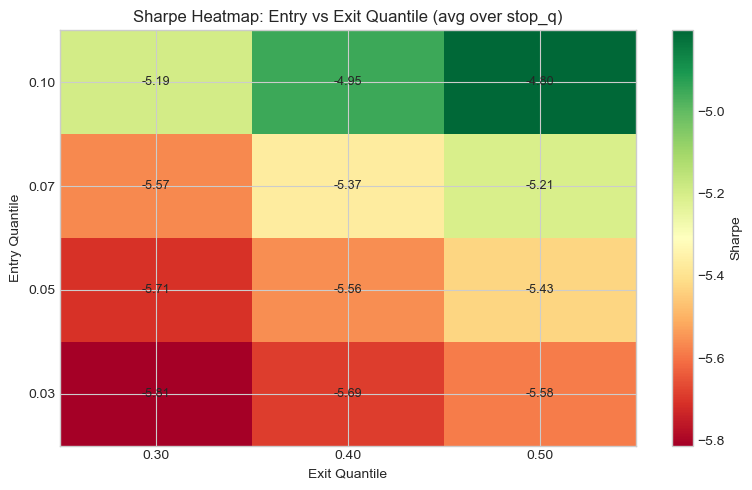

In [6]:
engine_q = make_engine()
q_rows = []
combos = list(itertools.product(ENTRY_QS, EXIT_QS, STOP_QS))

for eq, xq, sq in combos:
    if xq >= (1 - eq):  # invalid combination
        continue
    sig = QuantileZScoreSignal(entry_quantile = eq, exit_quantile = xq, stop_quantile = sq)
    m   = run_and_extract(engine_q, signal=sig)
    m.update({"entry_quantile": eq, "exit_quantile": xq, "stop_quantile": sq,
              "label": f"Q(e = {eq:.2f},x = {xq:.2f},s = {sq:.2f})", "type": "quantile"})
    q_rows.append(m)
    print(f"{m['label']}  Sharpe = {m['sharpe']:.3f}")

# fixed baseline
m_fixed = run_and_extract(engine_q, signal = ZScoreSignal(
    entry_z = DEFAULT_ENTRY_Z, exit_z = DEFAULT_EXIT_Z, stop_z = DEFAULT_STOP_Z))
m_fixed.update({"label": f"Fixed(e = {DEFAULT_ENTRY_Z}, x = {DEFAULT_EXIT_Z}, s = {DEFAULT_STOP_Z})",
                 "type": "fixed"})

q_df = pd.DataFrame(q_rows)
fixed_df = pd.DataFrame([m_fixed])

# comparison table — fixed + top 5 quantile configs
top5 = q_df.sort_values("sharpe", ascending = False).head(5)
comp = pd.concat([fixed_df, top5], ignore_index = True)
print("\nFixed vs Top 5 Quantile Configurations:")
display(comp[["label", "type", "sharpe", "fitness", "annualized_return", "max_drawdown", "turnover", "n_trades"]].round(4))

# heatmap
if "entry_quantile" in q_df.columns:
    pivot = q_df.groupby(["entry_quantile", "exit_quantile"])["sharpe"].mean().unstack()
    fig, ax = plt.subplots(figsize = (8, 5))
    im = ax.imshow(pivot.values, aspect = "auto", cmap = "RdYlGn", origin = "lower")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    ax.set_xlabel("Exit Quantile")
    ax.set_ylabel("Entry Quantile")
    ax.set_title("Sharpe Heatmap: Entry vs Exit Quantile (avg over stop_q)")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha = "center", va = "center", fontsize = 9)
    fig.colorbar(im, ax = ax, label = "Sharpe")
    plt.tight_layout()
    plt.show()

### Interpretation: Entry/Exit Threshold Sensitivity
**What this testing is for**:
The strategy needs two rules:
+ Entry threshold: How far apart must the stock prices get before we make a trade? (bigger gap = fewer but more confident trades)
+ Exit threshold: How close must they come back together before we close the trade and take profit?

"Quantile" just means these thresholds are set adaptively based on each pair's own historical behaviour, rather than using the same fixed number for every pair. "e" = entry, "x" = exit, "s" = stop-loss (a safety limit to cut losses).

**What the results show**:
+ Comparison table:
    + The fixed threshold baseline is bad (Sharpe of -2.94, making 5,006 trades with 27.34 turnover.) It's trading far too frequently on signals that don't work.
    + Every single quantile configuration beats the fixed baseline, and the best one (e = 0.10, x = 0.50, s = 0.00) actually achieves positive Sharpe (0.40) and positive annual return (+0.88%) —-> the only configuration in the entire analysis to do under realistic conditions.
    + **Higher entry** is better than lower entry --> waiting for a bigger price gap before trading produces better results
    + **Higher exit** is better than lower exit —-> letting the trade run longer before closing it captures more of the mean-reversion
    + No stop-loss (s = 0.00) works better —-> premature stop-outs are cutting winning trades short
    + Trade count drops dramatically from 5,006 (fixed) to just 389–584 (quantile). --> Less trading, better results. This ties back to the transaction cost finding.
+ Heatmap:
     + The colour pattern is very clear; top-right is best (dark green), bottom-left is worst (dark red). 
     + **High entry** quantile (0.10) + **high exit** quantile (0.50) = **best Sharpe** (~-4.80, darkest green)
     + Low entry quantile (0.03) + low exit quantile (0.30) = worst Sharpe (~-5.81, darkest red)
     + Heatmap Sharpe values are **all negative** and much worse than the table above. This is because the heatmap averages over all stop-loss settings including bad ones, which drags the numbers down. The table shows the best individual configurations. Averaging over stop-loss settings penalises everything.
     + The gradient is smooth and consistent (no erratic jumps) which actually means the strategy responds predictably to threshold changes, a sign of a well-behaved system even if absolute performance is poor.

**Conclusion/takeaway**
+ The fixed baseline's failure is largely driven by overtrading, while quantile thresholds naturally reduce trade frequency and thus cost drag. 
+ Wait for a big enough gap (high entry), let it fully close (high exit), and don't panic-exit early (no stop-loss).

## **7. Stop-Loss Threshold**

Tests whether enabling a stop-loss improves or hurts performance. A stop-loss forces the strategy to exit a losing trade early when the z-score exceeds a threshold, limiting downside but potentially increasing turnover and cutting off eventual profitable reversions.

Here we sweep `stop_quantile` values (0.0 = no stop-loss, lower = tighter stop).

Running stop-loss sweep...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

No stop-loss...
[2010_2012]  selected= 50  |  tradable= 50  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=QuantileZScoreSignal
[2011_2013]  selected= 29  |  tradable= 29  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=QuantileZScoreSignal
[2012_2014]  selected= 50  |  tradable= 50  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=QuantileZScoreSignal
[2013_2015]  selected= 50  |  tradable= 50  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=QuantileZScoreSignal
Sharpe=0.032  Turnover=229.79%  MaxDD=-3.07%
stop_q=0.005...
[2010_2012]  selected= 50  |  tradable= 50  |  test 2

,label,sharpe,fitness,annualized_return,max_drawdown,turnover,n_trades
0,No stop-loss,0.0324,0.0006,0.0007,-0.0307,2.2979,405
1,stop_q=0.005,-10.0641,-0.4267,-0.1722,-0.5303,95.7817,16967
2,stop_q=0.010,-11.1520,-0.4726,-0.1826,-0.5537,101.6797,18009
3,stop_q=0.020,-12.8055,-0.5417,-0.1970,-0.5842,110.0752,19523
4,stop_q=0.050,-9.7101,-0.4072,-0.1599,-0.5018,90.9007,16111


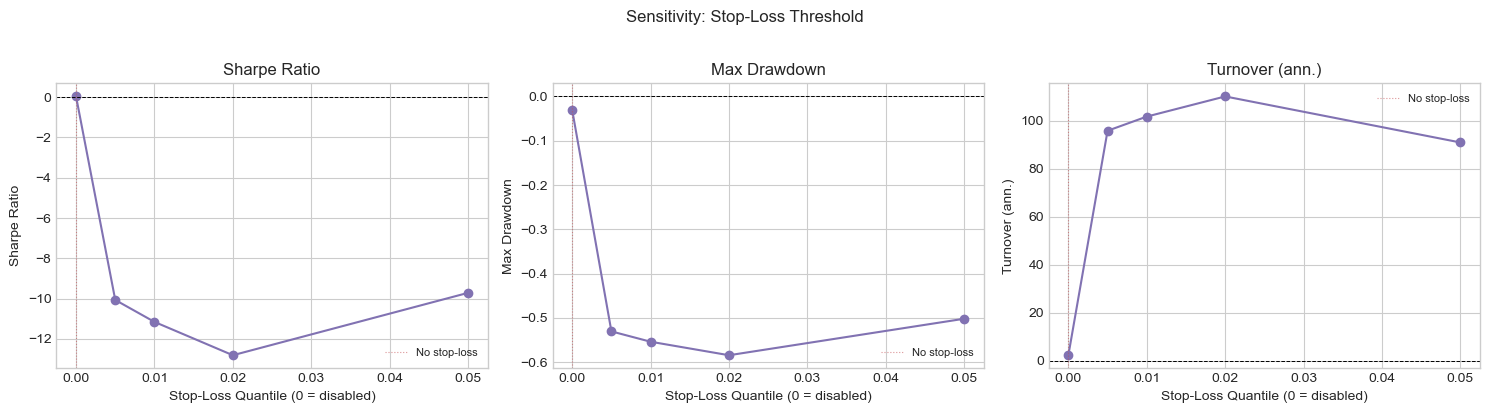

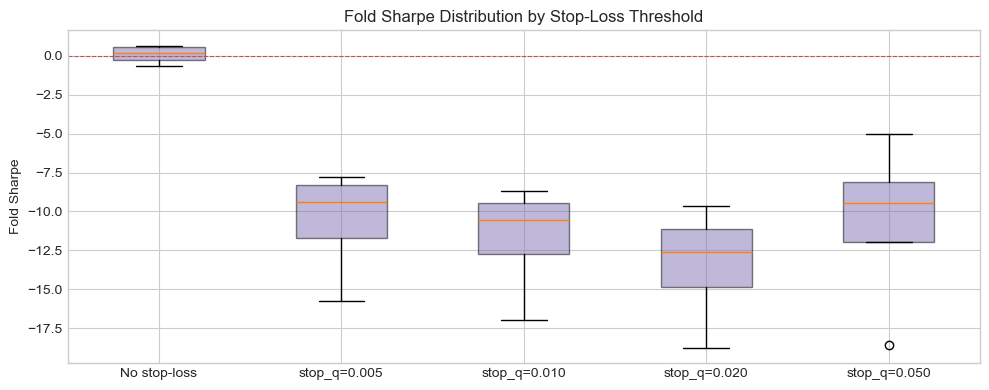

In [18]:
STOP_Q_GRID = [0.0, 0.005, 0.01, 0.02, 0.05]  # 0.0 = no stop-loss

print("Running stop-loss sweep...")
sl_rows = []
engine_sl = make_engine()
for sq in STOP_Q_GRID:
    label = "No stop-loss" if sq == 0.0 else f"stop_q={sq:.3f}"
    print(f"{label}...")
    sig = QuantileZScoreSignal(
        entry_quantile=DEFAULT_BACKTEST_PARAMS.entry_quantile,
        exit_quantile=DEFAULT_BACKTEST_PARAMS.exit_quantile,
        stop_quantile=sq,
    )
    m = run_and_extract(engine_sl, signal=sig)
    m["stop_quantile"] = sq
    m["label"] = label
    sl_rows.append(m)
    print(f"Sharpe={m['sharpe']:.3f}  Turnover={m.get('turnover', float('nan')):.2%}  MaxDD={m['max_drawdown']:.2%}")

sl_df = pd.DataFrame(sl_rows)
display(sl_df[["label", "sharpe", "fitness", "annualized_return",
               "max_drawdown", "turnover", "n_trades"]].round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, ylabel in zip(
    axes,
    ["sharpe", "max_drawdown", "turnover"],
    ["Sharpe Ratio", "Max Drawdown", "Turnover (ann.)"],
):
    ax.plot(sl_df["stop_quantile"], sl_df[metric], marker="o", color=PURPLE, linewidth=1.5)
    ax.set_xlabel("Stop-Loss Quantile (0 = disabled)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    # highlight no-stop baseline
    ax.axvline(0, color=RED, linewidth=0.8, linestyle=":", alpha=0.6, label="No stop-loss")
    ax.legend(fontsize=8)
fig.suptitle("Sensitivity: Stop-Loss Threshold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# fold-level box plot
fig, ax = plt.subplots(figsize=(10, 4))
data   = [row["fold_sharpes"] for row in sl_rows]
labels = [row["label"] for row in sl_rows]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(PURPLE)
    patch.set_alpha(0.5)
ax.axhline(0, color=RED, linestyle="--", linewidth=0.8)
ax.set_title("Fold Sharpe Distribution by Stop-Loss Threshold")
ax.set_ylabel("Fold Sharpe")
plt.tight_layout()
plt.show()

### Interpretation: Stop-Loss Threshold Sensitivity

**What this testing is for**:
A stop-loss forces the strategy to exit a losing trade early when the spread moves too far in the wrong direction, instead of waiting for it to revert. The idea is to limit how much you can lose on any single trade. Here we test whether adding a stop-loss helps or hurts overall performance.

**What the results show**:
+ Table & Line Charts:
    + No stop-loss is by far the best setting (Sharpe = 0.0324, return = +0.07%, only 405 trades). It is the only configuration that is profitable.
    + The moment any stop-loss is enabled, performance collapses dramatically. 
    + A stop-loss increases the number of trades from 405 to 16,000–19,000. The stop-loss is being triggered constantly, forcing the strategy to exit and re-enter trades at a huge cost.
    + Max drawdown also worsens significantly with any stop-loss.

+ Box Plot:
    + The no stop-loss box sits right at zero, small and tight — performance is consistent and almost break-even across all folds.
    + Every other setting has boxes far below zero, with wide spreads meaning performance is both terrible and inconsistent across folds.

**Conclusion/takeaway**:
Stop-losses are actively harmful for this strategy. The reason is that pairs trading relies on mean reversion. The spread is supposed to wander away and then come back. A stop-loss exits the trade when it wanders away, which is exactly the wrong moment to exit. The strategy then has to re-enter later at a cost. Thus, **do not use a stop-loss for this strategy**.

## **8. Min Pair Score Threshold**

Tests whether using stricter pair quality criteria improves performance. `min_score` filters out pairs with a cointegration/quality score below the threshold. Higher means only the best pairs are traded.

The trade-off: stricter filtering reduces noise but also reduces the number of pairs traded, concentrating risk.

Running min pair score sweep...
  min_score = 0.0...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

[2010_2012]  selected= 50  |  tradable= 50  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=ZScoreSignal
[2011_2013]  selected= 29  |  tradable= 29  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=ZScoreSignal
[2012_2014]  selected= 50  |  tradable= 50  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=ZScoreSignal
[2013_2015]  selected= 50  |  tradable= 50  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=ZScoreSignal
    Sharpe=-0.851  N_trades=1511  MaxDD=-8.62%
  min_score = 0.1...
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Yea

,min_score,sharpe,fitness,annualized_return,max_drawdown,turnover,n_trades
0,0.0,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
1,0.1,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
2,0.2,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
3,0.3,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
4,0.5,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511
5,0.7,-0.8508,-0.0368,-0.0159,-0.0862,8.4817,1511


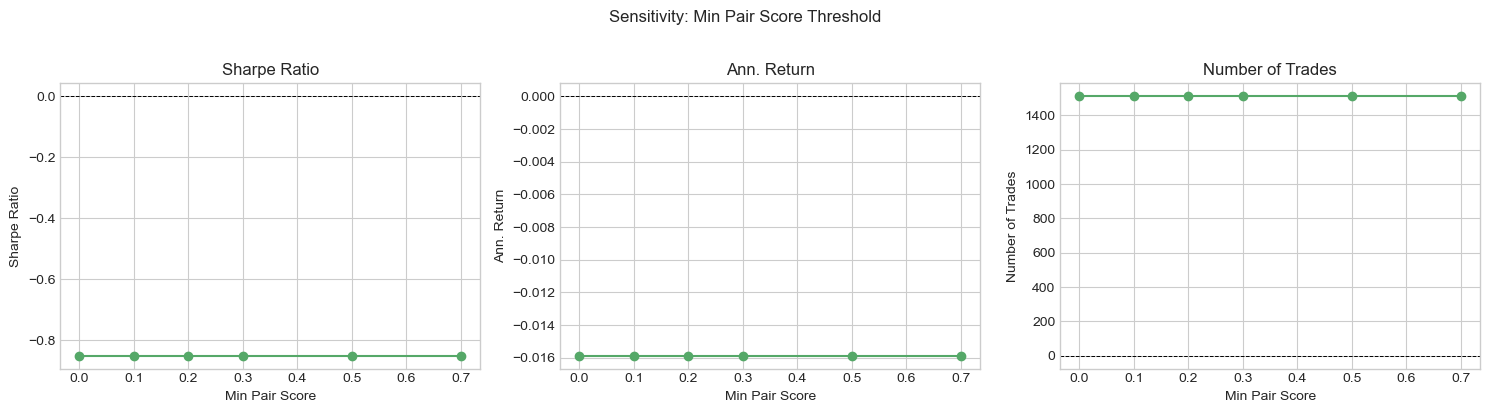

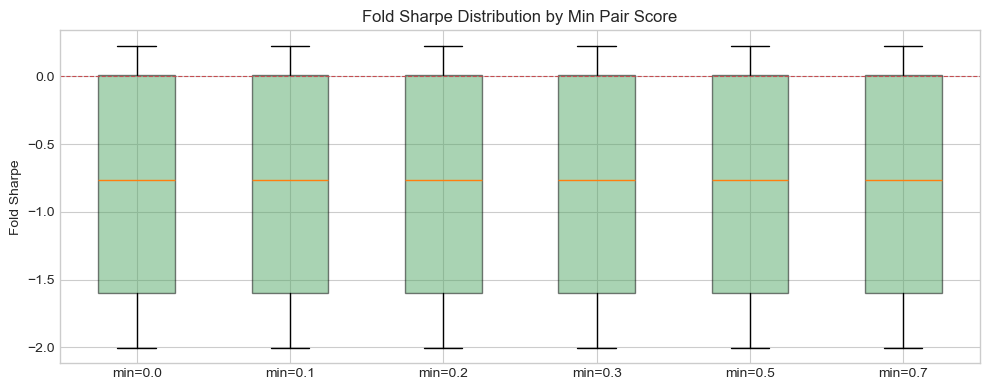

In [13]:
MIN_SCORE_GRID = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]

print("Running min pair score sweep...")
ms_rows = []
for ms in MIN_SCORE_GRID:
    print(f"  min_score = {ms}...")
    cfg = BacktestConfig(
        entry_z              = DEFAULT_ENTRY_Z,
        exit_z               = DEFAULT_EXIT_Z,
        stop_z               = DEFAULT_STOP_Z,
        n_top_pairs          = DEFAULT_N_PAIRS,
        transaction_cost_bps = DEFAULT_TC_BPS,
        use_rolling_zscore   = True,
        rolling_lookback     = DEFAULT_LOOKBACK,
        min_score            = ms,
    )
    engine_ms = BacktestEngine(cfg)
    engine_ms.load_data(
        str(DEFAULT_CONFIG.engineered_features_path),
        str(PROCESSED / "discovered_pairs.csv"),
    )
    m = run_and_extract(engine_ms)
    m["min_score"] = ms
    ms_rows.append(m)
    print(f"    Sharpe={m['sharpe']:.3f}  N_trades={m.get('n_trades', 0)}  MaxDD={m['max_drawdown']:.2%}")

ms_df = pd.DataFrame(ms_rows)
display(ms_df[["min_score", "sharpe", "fitness", "annualized_return",
               "max_drawdown", "turnover", "n_trades"]].round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, ylabel in zip(
    axes,
    ["sharpe", "annualized_return", "n_trades"],
    ["Sharpe Ratio", "Ann. Return", "Number of Trades"],
):
    ax.plot(ms_df["min_score"], ms_df[metric], marker="o", color=GREEN, linewidth=1.5)
    ax.set_xlabel("Min Pair Score")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
fig.suptitle("Sensitivity: Min Pair Score Threshold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# fold-level box plot
fig, ax = plt.subplots(figsize=(10, 4))
data   = [row["fold_sharpes"] for row in ms_rows]
labels = [f"min={row['min_score']}" for row in ms_rows]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(GREEN)
    patch.set_alpha(0.5)
ax.axhline(0, color=RED, linestyle="--", linewidth=0.8)
ax.set_title("Fold Sharpe Distribution by Min Pair Score")
ax.set_ylabel("Fold Sharpe")
plt.tight_layout()
plt.show()

### Interpretation: Min Pair Score Threshold Sensitivity

**What this testing is for**:
When pairs are discovered, each one is given a quality score based on how strongly cointegrated the two stocks are. The `min_score` parameter filters out pairs below a certain quality threshold — only pairs with a score above this value are traded. The idea is that trading only the best-quality pairs should produce better results.

**What the results show**:
+ Table & Line Charts:
    + Every single metric is completely identical across all six min_score values.
    + The three line charts are completely flat. There is no change in performance no matter how strict the quality filter is.

+ Fold Sharpe Box Plot:
    + All six boxes are identical in shape, size, and position with median around -0.8.

**Conclusion/takeaway**:
All selected pairs already have scores above 0.7, so raising the threshold don't actually filter anything out. The `min_score` parameter therefore has no practical effect in this pipeline, not because pair quality doesn't matter, but because all selected pairs are already high quality.

## **9. Sensitivity Summary**

`sharpe_range` = max Sharpe − min Sharpe across the grid for each hyperparameter.
A large range means the strategy is sensitive (fragile) to that parameter.
A small range means it is robust.

,hyperparameter,sharpe_min,sharpe_max,sharpe_range,sharpe_mean,sharpe_std,pct_positive_folds,sensitivity_verdict
0,Lookback window (days),-1.4111,-0.1962,1.2148,-0.7440,0.5026,0.25,HIGH
1,Number of pairs,-0.8508,-0.5413,0.3094,-0.6910,0.1450,0.35,MEDIUM
2,Transaction cost (bps),-2.5801,0.0514,2.6315,-1.1029,1.0571,0.25,HIGH
3,Entry/exit threshold (quantile),-11.6750,0.3962,12.0712,-5.4060,5.6857,0.29,HIGH
4,Stop-loss threshold,-12.8055,0.0324,12.8379,-8.7399,5.0496,0.10,HIGH
5,Min pair score,-0.8508,-0.8508,0.0000,-0.8508,0.0000,0.25,LOW


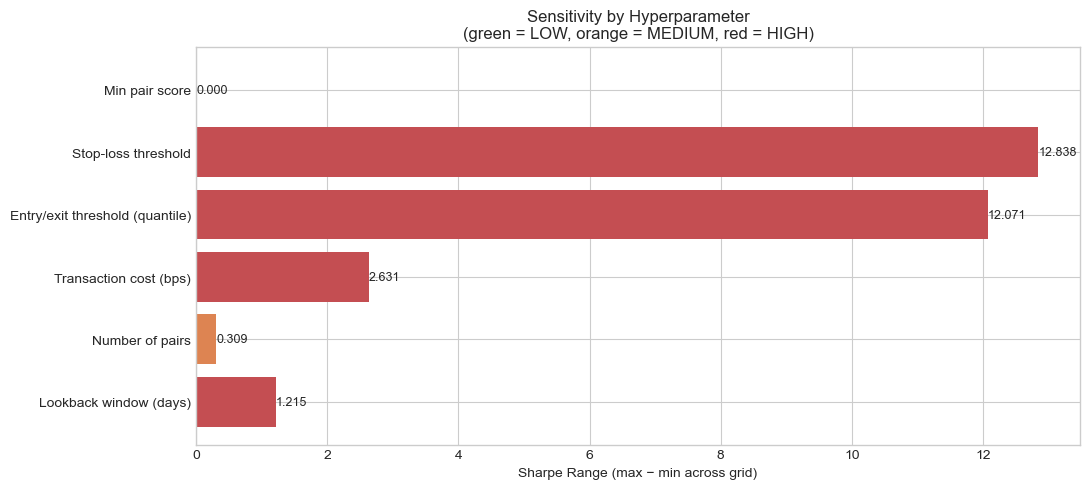

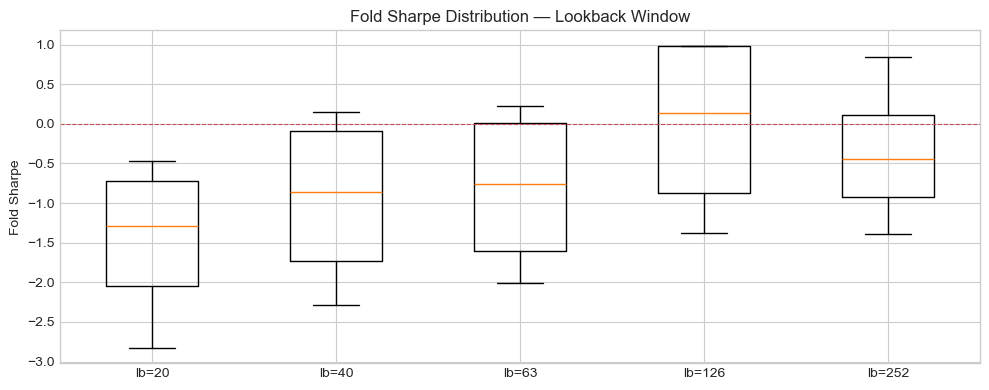

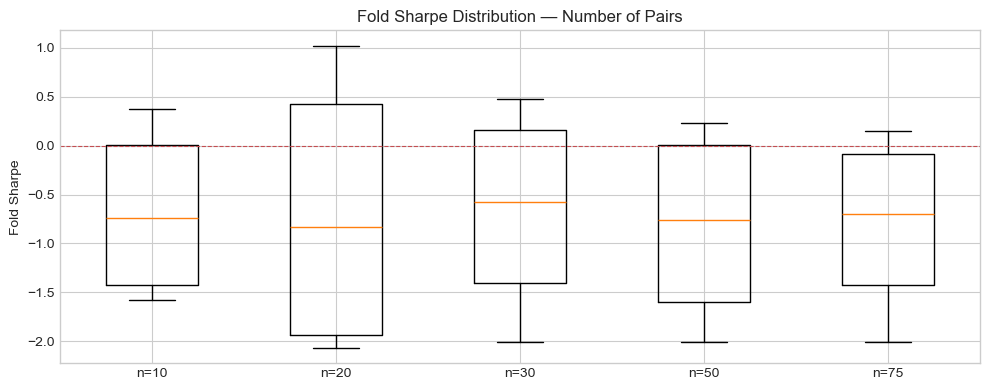

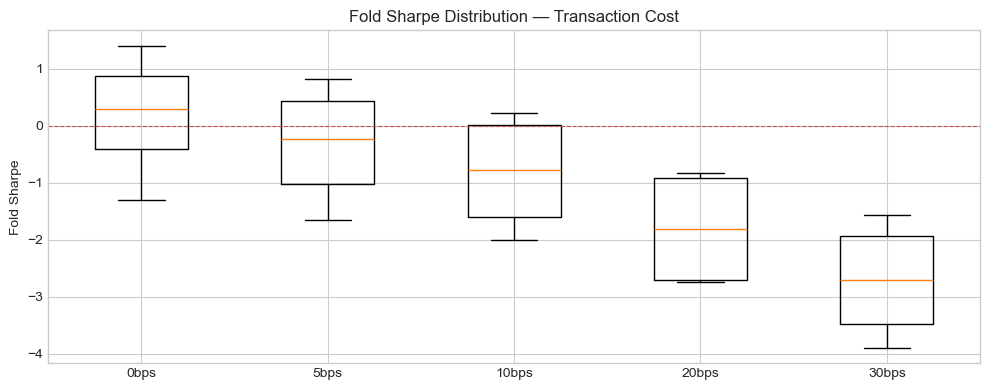

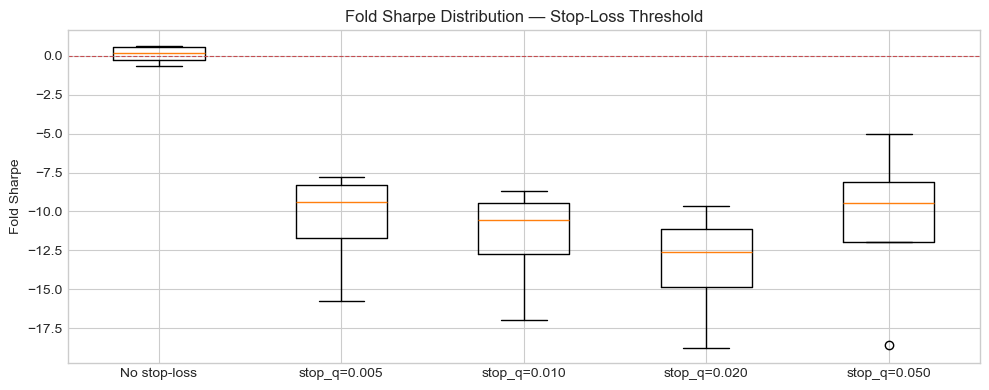

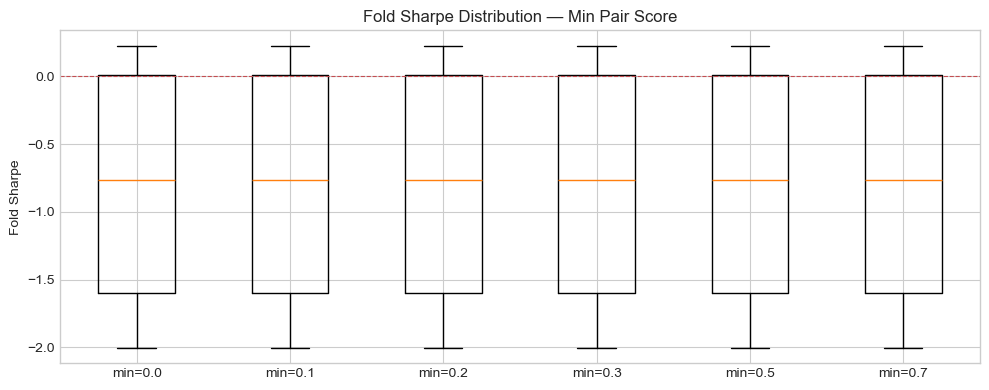

In [ ]:
summary_rows = []
for name, df, param_col, rows in [
    ("Lookback window (days)", lb_df, "lookback", lb_rows),
    ("Number of pairs", np_df, "n_pairs", np_rows),
    ("Transaction cost (bps)", tc_df, "tc_bps", tc_rows),
    ("Entry/exit threshold (quantile)", q_df, "entry_quantile", q_rows),
    ("Stop-loss threshold", sl_df, "stop_quantile", sl_rows),
    ("Min pair score", ms_df, "min_score", ms_rows),
]:
    if df.empty or "sharpe" not in df.columns:
        continue
    sharpes = df["sharpe"].dropna()
    fold_sharpes_all = [s for row in rows for s in row.get("fold_sharpes", [])]
    n_pos = sum(1 for s in fold_sharpes_all if s > 0)
    summary_rows.append({
        "hyperparameter": name,
        "sharpe_min": round(sharpes.min(),  4),
        "sharpe_max": round(sharpes.max(),  4),
        "sharpe_range": round(sharpes.max() - sharpes.min(), 4),
        "sharpe_mean": round(sharpes.mean(), 4),
        "sharpe_std": round(sharpes.std(),  4),
        "pct_positive_folds": round(n_pos / len(fold_sharpes_all), 2) if fold_sharpes_all else None,
        "sensitivity_verdict": "HIGH" if sharpes.std() > 0.3 else "MEDIUM" if sharpes.std() > 0.1 else "LOW",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# sensitivity bar chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = [GREEN if v == "LOW" else ORANGE if v == "MEDIUM" else RED
          for v in summary_df["sensitivity_verdict"]]
bars = ax.barh(summary_df["hyperparameter"], summary_df["sharpe_range"], color=colors)
ax.set_xlabel("Sharpe Range (max − min across grid)")
ax.set_title("Sensitivity by Hyperparameter\n(green = LOW, orange = MEDIUM, red = HIGH)")
ax.axvline(0, color="black", linewidth=0.7)
for bar, val in zip(bars, summary_df["sharpe_range"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# fold Sharpe box plots for each sweep
sweep_list = [
    (lb_rows,  "lookback",       "Lookback Window",        [f"lb={r['lookback']}"         for r in lb_rows]),
    (np_rows,  "n_pairs",        "Number of Pairs",        [f"n={r['n_pairs']}"           for r in np_rows]),
    (tc_rows,  "tc_bps",         "Transaction Cost",       [f"{r['tc_bps']}bps"           for r in tc_rows]),
    (sl_rows,  "stop_quantile",  "Stop-Loss Threshold",    [r["label"]                    for r in sl_rows]),
    (ms_rows,  "min_score",      "Min Pair Score",         [f"min={r['min_score']}"       for r in ms_rows]),
]
for rows, param_col, title, labels in sweep_list:
    fig, ax = plt.subplots(figsize=(10, 4))
    data = [r["fold_sharpes"] for r in rows]
    ax.boxplot(data, labels=labels)
    ax.axhline(0, color=RED, linestyle="--", linewidth=0.8)
    ax.set_title(f"Fold Sharpe Distribution — {title}")
    ax.set_ylabel("Fold Sharpe")
    plt.tight_layout()
    plt.show()


### Interpretation: Sensitivity Summary

**What the results show**:

+ Image 1 & 2 — Summary Table & Bar Chart:
    + Stop-loss threshold has the largest Sharpe range (12.84). Enabling a stop-loss immediately destroys performance.
    + Entry/exit threshold (range = 12.07) is also sensitive. High entry and high exit thresholds give are optimal.
    + Transaction cost (range = 2.63) —-> the strategy has almost no profit buffer against real-world fees.
    + Lookback window (range = 1.21) —-> still HIGH sensitivity, but more manageable.
    + Number of pairs (range = 0.31) is MEDIUM --> the strategy is relatively forgiving here.
    + Min pair score (range = 0.00) is LOW —-> no effect at all, since all selected pairs already pass the strictest threshold.

+ Image 3 — Fold Sharpe by Lookback Window:
    + Clear improvement from left to right up to lb = 126, which is the only setting where the box straddles zero and the median is close to break-even. lb = 252 slightly worsens again.

+ Image 4 — Fold Sharpe by Number of Pairs:
    + n = 20 has the widest upside reach (+1.0). 

+ Image 5 — Fold Sharpe by Transaction Cost:
    + At 0bps, the only setting where the median fold Sharpe is above zero, meaning the strategy is profitable on average across periods only when there are no trading fees. 

+ Image 6 — Fold Sharpe by Stop-Loss Threshold:
    + The no stop-loss box sits tight around zero --> small, consistent, and close to break-even. 
    + Every other setting has boxes collapsed far below zero.

+ Image 7 — Fold Sharpe by Min Pair Score:
    + All six boxes are completely identical —-> confirming that this parameter has zero effect on performance.

**Conclusion/takeaway**:
**Stop-loss threshold, entry/exit threshold, transaction cost, and lookback window are HIGH sensitivity**. This strategy's performance depends heavily on configuration choices. The most important findings are: 
1. Never use a stop-loss. It destroys the strategy by triggering excessive trading.
2. Always use adaptive quantile thresholds instead of fixed z-score rules. (Wait for a big enough gap (high entry), let it fully close (high exit))
3. 0 transaction cost is the only condition that is marginally profitable, though this is an unrealistic condition in real markets.
4. Optimal lookback window = 126 days

Based on our findings, the strategy's biggest problem is that it doesn't make enough profit per trade to cover the cost of making that trade. The best way to fix this is simply to trade less, which means using a longer lookback window and waiting for a bigger price gap before entering a trade.

## **10. Per-Fold Robustness of Best Configuration**

Takes the single best configuration found across all sensitivity sweeps and shows how it performs fold-by-fold. A strategy that looks good in aggregate but only works in one or two years is not robust.

This answers: *is the performance we found consistent across time, or was it driven by one lucky period?*

Best configuration from all validation sweeps:
Lookback: 126 days
Number of pairs: 20
Transaction cost: 0.0 bps
Min pair score: 0.0
[BacktestEngine] Loading prices  → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/mabelaugustine/Desktop/Year 3/CS3244/Final Project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,523 total pairs | 535 eligible

[2010_2012]  selected= 20  |  tradable= 20  |  test 2013-01-01 → 2013-12-31  (252 days)  |  model=ZScoreSignal
[2011_2013]  selected= 20  |  tradable= 20  |  test 2014-01-01 → 2014-12-31  (252 days)  |  model=ZScoreSignal
[2012_2014]  selected= 20  |  tradable= 20  |  test 2015-01-01 → 2015-12-31  (252 days)  |  model=ZScoreSignal
[2013_2015]  selected= 20  |  tradable= 20  |  test 2016-01-01 → 2016-12-31  (252 days)  |  model=ZScoreSignal

Per-Fold Results — Best Configuration:


,fold,test_period,sharpe,annualized_return,max_drawdown,n_trades,turnover
0,2010_2012,2013-01-01 → 2013-12-31,2.7197,0.0296,-0.0049,108,5.4
1,2011_2013,2014-01-01 → 2014-12-31,-0.9862,-0.0201,-0.0285,93,4.7
2,2012_2014,2015-01-01 → 2015-12-31,-0.7557,-0.0146,-0.0269,84,4.2
3,2013_2015,2016-01-01 → 2016-12-31,1.9425,0.0582,-0.0249,84,4.2



Aggregate: Sharpe=0.599  Return=1.28%  MaxDD=-4.45%


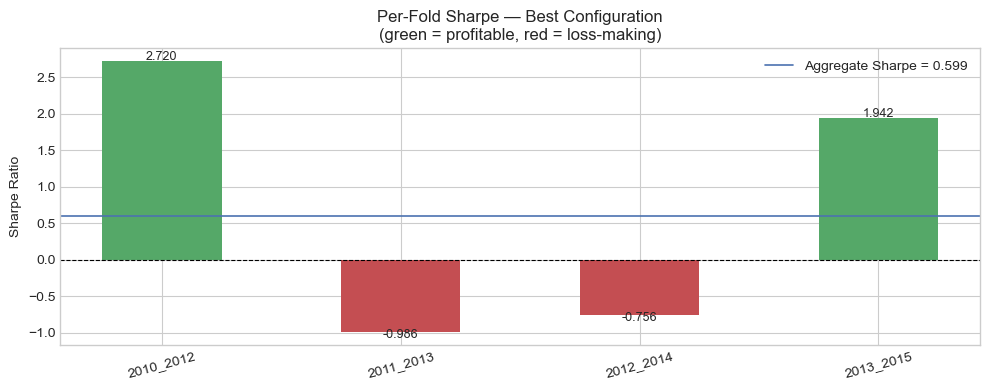

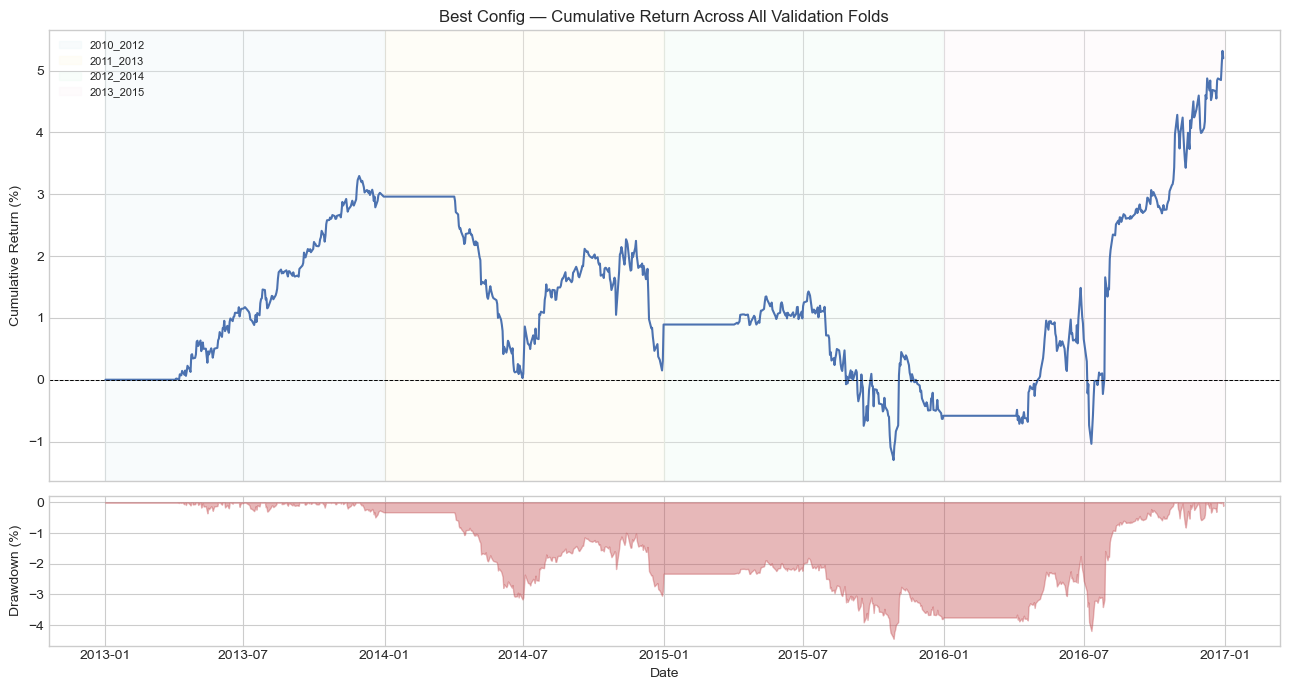

In [19]:
# pick the best config from all sweeps run so far
best_lookback = int(lb_df.loc[lb_df["sharpe"].idxmax(), "lookback"]) if not lb_df.empty else DEFAULT_LOOKBACK
best_n_pairs = int(np_df.loc[np_df["sharpe"].idxmax(), "n_pairs"])  if not np_df.empty else DEFAULT_N_PAIRS
best_tc = float(tc_df.loc[tc_df["sharpe"].idxmax(), "tc_bps"]) if not tc_df.empty else DEFAULT_TC_BPS
best_ms = float(ms_df.loc[ms_df["sharpe"].idxmax(), "min_score"]) if not ms_df.empty else 0.0

print("Best configuration from all validation sweeps:")
print(f"Lookback: {best_lookback} days")
print(f"Number of pairs: {best_n_pairs}")
print(f"Transaction cost: {best_tc} bps")
print(f"Min pair score: {best_ms}")

# run the best config and extract per-fold results
cfg_best = BacktestConfig(
    entry_z = DEFAULT_ENTRY_Z,
    exit_z = DEFAULT_EXIT_Z,
    stop_z = DEFAULT_STOP_Z,
    n_top_pairs = best_n_pairs,
    transaction_cost_bps = best_tc,
    use_rolling_zscore = True,
    rolling_lookback = best_lookback,
    min_score = best_ms,
)
engine_best = BacktestEngine(cfg_best)
engine_best.load_data(
    str(DEFAULT_CONFIG.engineered_features_path),
    str(PROCESSED / "discovered_pairs.csv"),
)
best_results = engine_best.run()

# extract per-fold metrics
fold_rows = []
for window, res in best_results.items():
    if window == "__aggregate__":
        continue
    m = res.get("metrics", {})
    fold_rows.append({
        "fold": window,
        "test_period": f"{res.get('test_start', '')} → {res.get('test_end', '')}",
        "sharpe": round(m.get("sharpe", float("nan")), 4),
        "annualized_return":round(m.get("annualized_return", float("nan")), 4),
        "max_drawdown": round(m.get("max_drawdown", float("nan")), 4),
        "n_trades": m.get("n_trades", 0),
        "turnover": round(m.get("turnover", float("nan")), 4),
    })

fold_df = pd.DataFrame(fold_rows)
agg_m = best_results.get("__aggregate__", {}).get("metrics", {})

print("\nPer-Fold Results — Best Configuration:")
display(fold_df)
print(f"\nAggregate: Sharpe={agg_m.get('sharpe', float('nan')):.3f}  "
      f"Return={agg_m.get('annualized_return', float('nan')):.2%}  "
      f"MaxDD={agg_m.get('max_drawdown', float('nan')):.2%}")

# plot 1: bar chart of per-fold Sharpe
fig, ax = plt.subplots(figsize=(10, 4))
colors  = [GREEN if s > 0 else RED for s in fold_df["sharpe"]]
bars    = ax.bar(fold_df["fold"], fold_df["sharpe"], color=colors, width=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(agg_m.get("sharpe", 0), color=BLUE, linewidth=1.2, linestyle="-",
           label=f"Aggregate Sharpe = {agg_m.get('sharpe', 0):.3f}")
for bar, val in zip(bars, fold_df["sharpe"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.02 if val >= 0 else val - 0.08,
            f"{val:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Per-Fold Sharpe — Best Configuration\n(green = profitable, red = loss-making)")
ax.set_xticklabels(fold_df["fold"], rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

# plot 2: cumulative return curve across all folds
agg = best_results.get("__aggregate__", {})
if "daily_returns" in agg:
    ret = agg["daily_returns"].dropna()
    cum = (1 + ret).cumprod()
    dd  = cum / cum.cummax() - 1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})
    ax1.plot(cum.index, (cum - 1) * 100, color=BLUE, linewidth=1.5)
    ax1.axhline(0, color="black", linewidth=0.7, linestyle="--")
    # shade each fold period
    fold_colors = ["#e8f4f8", "#fef9e7", "#eafaf1", "#fdf2f8"]
    for i, (_, frow) in enumerate(fold_df.iterrows()):
        try:
            start, end = frow["test_period"].split(" → ")
            ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                        alpha=0.3, color=fold_colors[i % len(fold_colors)],
                        label=frow["fold"])
        except Exception:
            pass
    ax1.set_ylabel("Cumulative Return (%)")
    ax1.set_title("Best Config — Cumulative Return Across All Validation Folds")
    ax1.legend(fontsize=8, loc="upper left")

    ax2.fill_between(dd.index, dd * 100, 0, color=RED, alpha=0.4)
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    plt.tight_layout()
    plt.show()

### Interpretation: Per-Fold Robustness of Best Configuration

**What this testing is for**:
Even if a strategy looks good in aggregate, it might only be working in one or two years while losing money in the others. This section takes the single best configuration found across all sensitivity sweeps and checks whether it performs consistently across every individual fold.

**What the results show**:

+ Bar Chart (Per-Fold Sharpe):
    + The aggregate Sharpe is 0.599 (blue line), which looks decent.
    + 2010_2012 (validates on 2013): Sharpe = 2.720 --> the strategy works well.
    + 2011_2013 (validates on 2014): Sharpe = -0.986 --> loss-making.
    + 2012_2014 (validates on 2015): Sharpe = -0.756 —-> loss-making.
    + 2013_2015 (validates on 2016): Sharpe = 1.942 --> the strategy works well.
    + The strategy is profitable in 2 out of 4 folds. The positive aggregate Sharpe is largely driven by the two strong years (2013 and 2016), which are large enough to offset the losses in 2014 and 2015.

+ Cumulative Return Chart:
    + 2013 (light blue shading): The strategy climbs steadily to ~3%, showing clean and consistent mean-reversion behaviour.
    + 2014 (no shading): Performance drops sharply from 3% back to near zero. The 2014 period clearly hurt.
    + 2015 (light green shading): Continued losses, dropping to nearly -1.5% at the worst point in mid-2015.
    + 2016 (light purple shading): A strong recovery, ending the period at ~5.3% cumulative return.
    + The drawdown panel shows persistent drawdowns of -3% to -4% throughout 2014–2016, meaning the strategy spent a long time before recovering.

**Conclusion/takeaway**:
The best configuration is not consistently profitable, it works well in some years and loses money in others. This shows the strategy does not perform steadily across all periods. The strategy is sensitive to market conditions and is not yet robust enough for reliable deployment.

## **11. Holdout Results (2017 - Final Unbiased Test)**

The best configuration from all validation sweeps is now evaluated on the held-out 2017 test set **exactly once**.
This is the unbiased estimate of real strategy performance. Do not re-run after seeing the result.

Running holdout (2017) with best config — run this only once.
  Lookback: 126 | N pairs: 20 | TC: 0.0 bps | Min score: 0.0
[2014_2016]  selected= 20  |  tradable= 20  |  test 2017-01-01 → 2017-12-31  (218 days)  |  model=ZScoreSignal

════════════════════════════════════════════════════════════════════════
  BACKTEST SUMMARY
════════════════════════════════════════════════════════════════════════
  Total Return                        -1.20%
  Annualised Return                   -1.39%
  Sharpe Ratio                         -1.01
  Max Drawdown                        -2.08%
  Volatility (ann.)                    1.37%
  Number of Trades                        76
  Turnover (ann.)                    439.27%
  Margin                             -0.06 ‰
  Fitness                              -0.06
════════════════════════════════════════════════════════════════════════

  Year    Sharpe   Turnover  Fitness   Returns   Drawdown     Margin   Long  Short
  ────────────────────────────────────

,total_return,annualized_return,sharpe,max_drawdown,volatility,n_trades,turnover,margin_permille,fitness
0,-0.012,-0.0139,-1.0133,-0.0208,0.0137,76,4.3927,-0.0633,-0.057


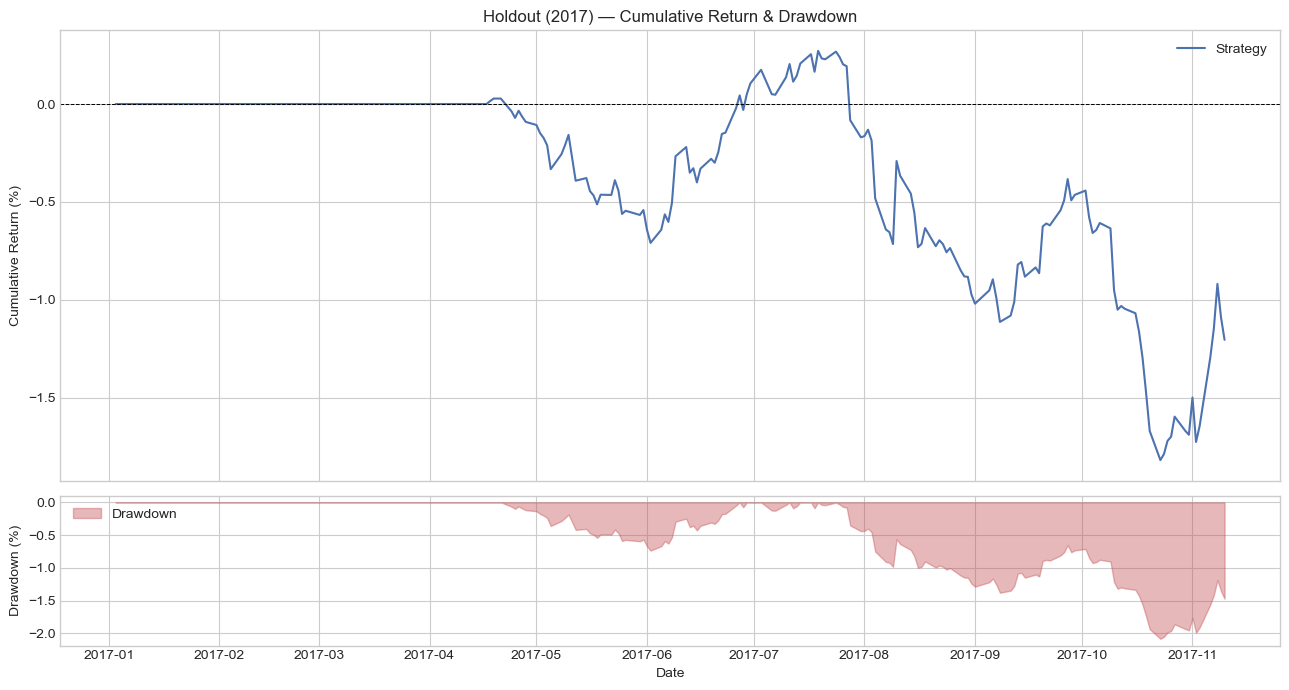

In [ ]:
print("Running holdout (2017) with best config — run this only once.")
print(f"Lookback: {best_lookback} | N pairs: {best_n_pairs} | TC: {best_tc} bps | Min score: {best_ms}")

holdout_results = engine_best.run_holdout()
engine_best.report(holdout_results)

agg_h   = holdout_results.get("__aggregate__", {})
metrics_h = agg_h.get("metrics", {})
display(pd.DataFrame([metrics_h]).round(4))

if "daily_returns" in agg_h:
    ret = agg_h["daily_returns"].dropna()
    cum = (1 + ret).cumprod()
    dd  = cum / cum.cummax() - 1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})
    ax1.plot(cum.index, (cum - 1) * 100, color=BLUE, linewidth=1.5, label="Strategy")
    ax1.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax1.set_ylabel("Cumulative Return (%)")
    ax1.set_title("Holdout (2017) — Cumulative Return & Drawdown")
    ax1.legend()
    ax2.fill_between(dd.index, dd * 100, 0, color=RED, alpha=0.4, label="Drawdown")
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    ax2.legend()
    plt.tight_layout()
    plt.show()

### Interpretation: Holdout Results (2017 — Final Unbiased Test)
This is the final test. The strategy is run on 2017 data exactly once, using the best configuration found during validation. This gives an unbiased estimate of how the strategy would actually perform in the real world.

**What the results show**:

+ Metrics Table:
    + Sharpe = -1.0133, annual return = -1.39%, total return = -1.2%. The strategy loses money in 2017.
    + Only 76 trades were made the entire year, with low turnover (4.39), meaning the strategy was selective and traded infrequently. The losses are not from overtrading.
    + Max drawdown = -2.08%, volatility = 1.37%. The drawdowns are relatively contained, but the strategy never recovers from them.

+ Cumulative Return Chart:
    + January to April 2017: The strategy sits completely flat with no trades. It found no opportunities worth entering.
    + April to June 2017: Activity begins but returns immediately drop to around -0.7%.
    + June to early August 2017: The strategy briefly makes profit (+0.2% peak in late July), the only profitable period of the year.
    + August to November 2017: A sustained decline with no recovery, ending at around -1.7% before an increase to -1.2% at year end.
    + The drawdown panel shows persistent drawdowns from April onwards, reaching a worst point of around -2.1% in late October/early November.

**Conclusion/takeaway**:
The holdout result confirms what the validation folds suggested. The strategy is not consistently profitable. 2017 was a bull market year (according to CBS News), which is a difficult environment for pairs trading since stocks tend to move together in one direction rather than mean-reverting. The strategy found very few opportunities (only 76 trades), and the ones it took mostly lost money. 